# 07 — Ajuste de hiperparámetros y segmentación

TFM — Emisiones de CO₂ de los vehículos nuevos matriculados en la UE.

Continúa el cuaderno 06, que estableció el rendimiento de referencia y acreditó
que el modelo se apoya en las variables físicas y no en la identidad comercial
del vehículo.

Objetivo: reducir el conjunto de variables a las que aportan señal, ajustar los
hiperparámetros del modelo de gradient boosting y segmentar el mercado mediante
aprendizaje no supervisado. Alimenta los apartados 4.7 y 4.9 de la memoria.

In [1]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import lightgbm as lgb

import estilo
estilo.aplicar()

RAIZ = Path.cwd().parent
LIMPIO = RAIZ / "datos" / "procesado" / "co2cars_2024_limpio.parquet"

SEMILLA = 42
N_HILOS = 6
OBJETIVO = "Ewltp (g/km)"

# El cuaderno 06 midió la contribución de cada variable. Se retira
# tiene_ecoinnov, cuya aportación fue exactamente nula por derivarse de
# Erwltp, y se conserva el resto para que el ajuste decida sobre ellas.
NUMERICAS = ["M (kg)", "Ec (cm3)", "Ep (KW)", "Erwltp (g/km)", "cil_por_kw"]
CATEGORICAS = ["ft_norm", "Fm", "marca_norm", "MS", "Mp"]


def es(n, dec=0):
    """Formato numérico español: punto de millar y coma decimal."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "·").replace(".", ",").replace("·", ".")


MILES = FuncFormatter(lambda v, _: es(v))


def metricas(nombre, y_real, y_pred):
    return {"modelo": nombre,
            "MAE": mean_absolute_error(y_real, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
            "R2": r2_score(y_real, y_pred)}


df = pd.read_parquet(LIMPIO)
comb = df[df["regimen"] == "Combustión"].copy()
comb["cil_por_kw"] = comb["Ec (cm3)"] / comb["Ep (KW)"]
comb = comb.dropna(subset=[OBJETIVO])

X = comb[NUMERICAS + CATEGORICAS].copy()
for col in CATEGORICAS:
    X[col] = X[col].astype("category")
y = comb[OBJETIVO]

# Misma semilla y misma estratificación que en el cuaderno 06: la partición
# es idéntica, de modo que las métricas son comparables entre ambos.
X_ent, X_pru, y_ent, y_pru = train_test_split(
    X, y, test_size=0.20, random_state=SEMILLA, stratify=X["ft_norm"])

print(f"Entrenamiento: {es(len(X_ent))}   Prueba: {es(len(X_pru))}")
print(f"Variables: {X.shape[1]}")

Entrenamiento: 671.747   Prueba: 167.937
Variables: 10


## 1. Dimensionamiento de la búsqueda

Antes de lanzar el ajuste conviene medir cuánto tarda un solo entrenamiento. El
número de combinaciones a explorar se decide con ese dato y no al revés, para
que la búsqueda tenga un coste conocido de antemano.

In [2]:
MUESTRA_BUSQUEDA = 250_000       # subconjunto para la búsqueda
PLIEGUES = 3
CANDIDATOS = 25

Xb = X_ent.sample(min(MUESTRA_BUSQUEDA, len(X_ent)), random_state=SEMILLA)
yb = y_ent.loc[Xb.index]

t0 = time.time()
lgb.LGBMRegressor(n_estimators=400, learning_rate=0.06, num_leaves=63,
                  n_jobs=1, random_state=SEMILLA, verbose=-1).fit(Xb, yb)
por_ajuste = time.time() - t0

total = CANDIDATOS * PLIEGUES * por_ajuste / N_HILOS
print(f"Un ajuste sobre {es(len(Xb))} filas con un hilo: {por_ajuste:.1f} s")
print(f"{CANDIDATOS} candidatos x {PLIEGUES} pliegues / {N_HILOS} procesos")
print(f"Estimación de la búsqueda: {total/60:.1f} minutos")

Un ajuste sobre 250.000 filas con un hilo: 4.9 s
25 candidatos x 3 pliegues / 6 procesos
Estimación de la búsqueda: 1.0 minutos


## 2. Ajuste de hiperparámetros

Se emplea búsqueda aleatoria en lugar de exhaustiva: con seis parámetros, una
rejilla completa exigiría miles de combinaciones, mientras que el muestreo
aleatorio del espacio alcanza resultados equivalentes con una fracción del coste.

El paralelismo se aplica en la búsqueda y no dentro del modelo. Repartirlo en
los dos niveles multiplicaría los procesos y resultaría más lento que no
paralelizar en absoluto.

In [3]:
ESPACIO = {
    "n_estimators":      [300, 500, 800, 1200],
    "learning_rate":     [0.02, 0.04, 0.06, 0.10],
    "num_leaves":        [31, 63, 127, 255],
    "min_child_samples": [10, 20, 50, 100],
    "subsample":         [0.7, 0.85, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
}

busqueda = RandomizedSearchCV(
    lgb.LGBMRegressor(n_jobs=1, random_state=SEMILLA, verbose=-1,
                      subsample_freq=1),
    ESPACIO, n_iter=CANDIDATOS, cv=PLIEGUES,
    scoring="neg_mean_absolute_error",
    n_jobs=N_HILOS, random_state=SEMILLA, verbose=0)

t0 = time.time()
busqueda.fit(Xb, yb)
print(f"Búsqueda completada en {(time.time()-t0)/60:.1f} minutos\n")

print("Mejores parámetros:")
for k, v in sorted(busqueda.best_params_.items()):
    print(f"  {k:<20} {v}")
print(f"\nMAE en validación cruzada: {-busqueda.best_score_:.3f} g/km")

Búsqueda completada en 7.1 minutos

Mejores parámetros:
  colsample_bytree     0.8
  learning_rate        0.06
  min_child_samples    20
  n_estimators         1200
  num_leaves           255
  subsample            0.7

MAE en validación cruzada: 1.314 g/km


In [4]:
# El modelo definitivo se reajusta sobre el conjunto de entrenamiento completo
# con los parámetros hallados, ahora sí usando todos los hilos disponibles.
t0 = time.time()
final = lgb.LGBMRegressor(**busqueda.best_params_, n_jobs=N_HILOS,
                          random_state=SEMILLA, verbose=-1, subsample_freq=1)
final.fit(X_ent, y_ent)
print(f"Reajuste sobre {es(len(X_ent))} filas: {time.time()-t0:.0f} s")

base = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.08, num_leaves=63,
                         n_jobs=N_HILOS, random_state=SEMILLA, verbose=-1)
base.fit(X_ent, y_ent)

comparativa = pd.DataFrame([
    metricas("LightGBM sin ajustar", y_pru, base.predict(X_pru)),
    metricas("LightGBM ajustado",    y_pru, final.predict(X_pru)),
])
comparativa["mejora MAE %"] = [np.nan,
    100 * (comparativa.MAE[0] - comparativa.MAE[1]) / comparativa.MAE[0]]
print("\n" + comparativa.round(3).to_string(index=False))

Reajuste sobre 671.747 filas: 21 s



              modelo  MAE  RMSE    R2  mejora MAE %
LightGBM sin ajustar 1.74 2.743 0.991           NaN
   LightGBM ajustado 1.23 2.183 0.994         29.33


## 3. Segmentación del mercado

El segundo objetivo específico del trabajo es agrupar los vehículos según su
perfil conjunto de emisiones, masa, potencia y cilindrada. A diferencia del
modelo de regresión, aquí no hay variable objetivo: los grupos emergen de la
propia estructura de los datos.

Las cuatro variables se estandarizan previamente, ya que sus escalas difieren en
tres órdenes de magnitud y la distancia euclídea quedaría dominada por la
cilindrada.

El número de grupos se decide con dos criterios que no tienen por qué coincidir.
El coeficiente de silueta mide lo limpia que resulta la separación y tiende
sistemáticamente a favorecer particiones con pocos grupos. El codo de la inercia
busca el punto a partir del cual añadir grupos deja de compactar. Cuando ambos
discrepan, conviene presentar las dos lecturas antes de elegir.

In [5]:
VARS_CLUSTER = ["Ewltp (g/km)", "M (kg)", "Ep (KW)", "Ec (cm3)"]
datos_cl = comb[VARS_CLUSTER].dropna()
escalador = StandardScaler()
Z = escalador.fit_transform(datos_cl)

# El coeficiente de silueta compara cada punto con su grupo y con el vecino más
# próximo. Su cálculo es cuadrático en el número de observaciones, así que se
# evalúa sobre una submuestra; la inercia sí se calcula sobre el total.
sub = np.random.default_rng(SEMILLA).choice(len(Z), 20_000, replace=False)

evaluacion = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=5, random_state=SEMILLA).fit(Z)
    evaluacion.append({
        "k": k,
        "inercia": km.inertia_,
        "silueta": silhouette_score(Z[sub], km.labels_[sub]),
    })
    print(f"  k = {k}   silueta = {evaluacion[-1]['silueta']:.4f}")

evaluacion = pd.DataFrame(evaluacion)
mejor_k = int(evaluacion.loc[evaluacion.silueta.idxmax(), "k"])
print(f"\nMejor número de grupos por silueta: k = {mejor_k}")

  k = 2   silueta = 0.5286


  k = 3   silueta = 0.4382


  k = 4   silueta = 0.3620


  k = 5   silueta = 0.3536


  k = 6   silueta = 0.3636


  k = 7   silueta = 0.3684


  k = 8   silueta = 0.3701

Mejor número de grupos por silueta: k = 2


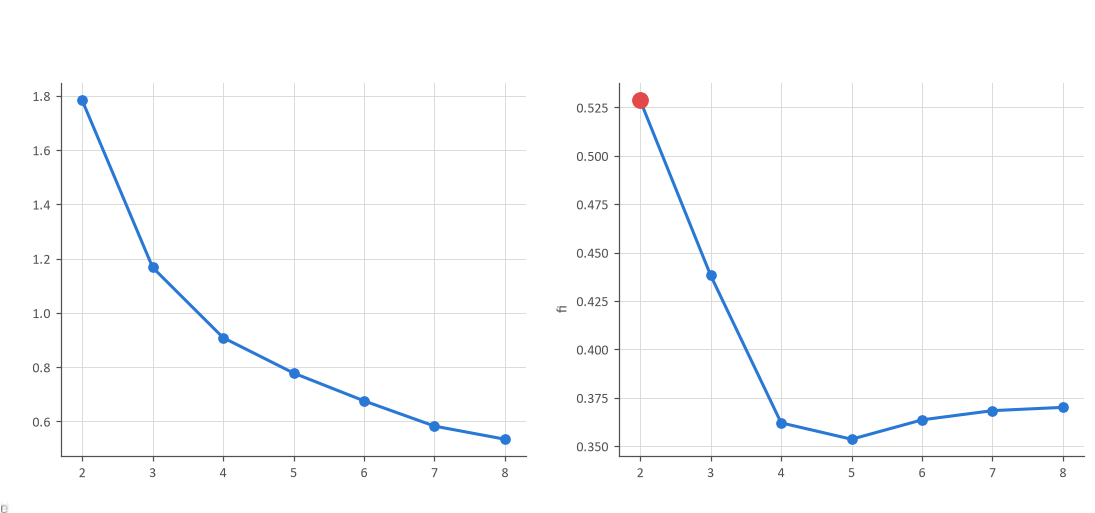

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

ax1.plot(evaluacion.k, evaluacion.inercia / 1e6, marker="o", ms=6, lw=2,
         color=estilo.PALETA[0])
ax1.set_xlabel("Número de grupos")
ax1.set_ylabel("Inercia (millones)")
ax1.set_title("Suma de distancias al centroide", fontsize=11, pad=10, loc="left")

ax2.plot(evaluacion.k, evaluacion.silueta, marker="o", ms=6, lw=2,
         color=estilo.PALETA[0])
ax2.plot(mejor_k, evaluacion.silueta.max(), marker="o", ms=10,
         color=estilo.PALETA[7], zorder=3)
ax2.set_xlabel("Número de grupos")
ax2.set_ylabel("Coeficiente de silueta")
ax2.set_title("Calidad de la separación entre grupos", fontsize=11, pad=10, loc="left")

fig.suptitle("Selección del número de grupos", fontsize=12.5, y=1.03)
fig.savefig(estilo.DIR_FIGURAS / "fig_11_seleccion_k.png")
plt.show()

### Dos particiones, dos lecturas

La silueta selecciona el mínimo número de grupos posible, mientras que el codo
de la inercia se sitúa más adelante. Se analizan por ello ambas particiones: la
que optimiza el criterio estadístico y la que resulta operativamente informativa.

In [7]:
K_ESTADISTICO = mejor_k          # el que maximiza la silueta
K_OPERATIVO = 4                  # el del codo de la inercia


def perfila(k, etiqueta):
    """Ajusta k grupos y devuelve su caracterización ordenada por emisiones."""
    modelo = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(Z)
    tabla = (datos_cl.assign(grupo=modelo.labels_)
             .groupby("grupo")
             .agg(vehiculos=(OBJETIVO, "size"),
                  co2=(OBJETIVO, "mean"),
                  masa=("M (kg)", "mean"),
                  potencia=("Ep (KW)", "mean"),
                  cilindrada=("Ec (cm3)", "mean"))
             .sort_values("co2"))
    tabla["pct"] = 100 * tabla.vehiculos / tabla.vehiculos.sum()

    aux = comb.loc[datos_cl.index].assign(grupo=modelo.labels_)
    tabla["combustible"] = [aux.loc[aux.grupo == g, "ft_norm"].mode()[0] for g in tabla.index]
    tabla["marca"] = [aux.loc[aux.grupo == g, "marca_norm"].mode()[0] for g in tabla.index]

    print(f"\n=== {etiqueta}: k = {k} ===")
    print(tabla.round(1).to_string())
    return modelo, tabla


modelo_est, perfil_est = perfila(K_ESTADISTICO, "Óptimo por silueta")
modelo_ope, perfil_ope = perfila(K_OPERATIVO, "Codo de la inercia")

datos_cl = datos_cl.assign(grupo_2=modelo_est.labels_, grupo_4=modelo_ope.labels_)


=== Óptimo por silueta: k = 2 ===
       vehiculos    co2    masa  potencia  cilindrada   pct combustible       marca
grupo                                                                              
1         667477  124.3  1336.7      84.2      1330.9  79.8      petrol  VOLKSWAGEN
0         168993  171.4  1837.1     163.0      2209.5  20.2      diesel         BMW



=== Codo de la inercia: k = 4 ===
       vehiculos    co2    masa  potencia  cilindrada   pct combustible       marca
grupo                                                                              
2         349570  118.4  1204.5      71.3      1128.3  41.8      petrol      TOYOTA
1         327355  131.0  1486.3      98.9      1565.9  39.1      petrol  VOLKSWAGEN
0         134013  161.9  1794.1     141.7      2036.6  16.0      diesel    MERCEDES
3          25532  233.3  2140.1     292.2      3202.1   3.1      petrol         BMW


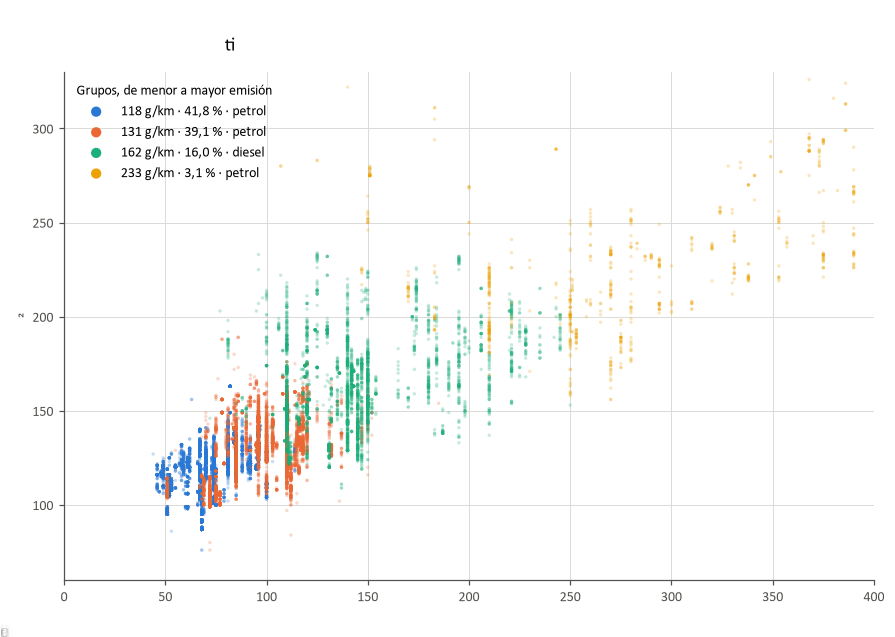

In [8]:
# La representación usa la partición operativa, que es la que aporta lectura
# de mercado. Los grupos se ordenan por emisiones medias para que la leyenda
# se recorra de menos a más contaminante.
orden = perfil_ope.index.tolist()

fig, ax = plt.subplots(figsize=(9.5, 6))
for i, g in enumerate(orden):
    m = (datos_cl.grupo_4 == g).values
    ax.scatter(datos_cl.loc[m, "Ep (KW)"][::30], datos_cl.loc[m, OBJETIVO][::30],
               s=5, alpha=0.25, color=estilo.PALETA[i], edgecolor="none",
               label=f"{perfil_ope.co2[g]:.0f} g/km · {es(perfil_ope.pct[g], 1)} % · "
                     f"{perfil_ope.combustible[g]}")

ax.set_xlabel("Potencia del motor (kW)")
ax.set_ylabel("Emisiones de CO₂ WLTP (g/km)")
ax.set_xlim(0, 400)
ax.set_ylim(60, 330)
leg = ax.legend(frameon=False, fontsize=9, markerscale=3, loc="upper left",
                title="Grupos, de menor a mayor emisión")
leg.get_title().set_fontsize(9)
for h in leg.legend_handles:
    h.set_alpha(1)
ax.set_title(f"Segmentación del mercado en {K_OPERATIVO} grupos\n"
             "Vehículos de combustión, UE 2024", fontsize=12.5, pad=14, loc="left")
fig.savefig(estilo.DIR_FIGURAS / "fig_12_segmentacion.png")
plt.show()

## 4. Persistencia del modelo

Se guardan el modelo ajustado y sus parámetros, de modo que el análisis de
interpretabilidad del cuaderno siguiente parta exactamente del mismo objeto y
no de un reentrenamiento.

In [9]:
DIR_MODELOS = RAIZ / "modelos"
DIR_MODELOS.mkdir(exist_ok=True)

final.booster_.save_model(str(DIR_MODELOS / "lightgbm_combustion.txt"))
(DIR_MODELOS / "hiperparametros.json").write_text(
    json.dumps({"parametros": busqueda.best_params_,
                "mae_prueba": float(comparativa.MAE[1]),
                "rmse_prueba": float(comparativa.RMSE[1]),
                "r2_prueba": float(comparativa.R2[1]),
                "semilla": SEMILLA,
                "n_entrenamiento": int(len(X_ent)),
                "variables": NUMERICAS + CATEGORICAS,
                "grupos_silueta": K_ESTADISTICO,
                "grupos_operativos": K_OPERATIVO}, indent=2, ensure_ascii=False),
    encoding="utf-8")

datos_cl[["grupo_2", "grupo_4"]].to_parquet(
    RAIZ / "datos" / "procesado" / "grupos_kmeans.parquet")

print("Guardado en modelos/:")
print("  lightgbm_combustion.txt")
print("  hiperparametros.json")
print("\nSegmentación en datos/procesado/grupos_kmeans.parquet")

Guardado en modelos/:
  lightgbm_combustion.txt
  hiperparametros.json

Segmentación en datos/procesado/grupos_kmeans.parquet
